# 05 — VLOG: DINOv2 임베딩 → 클러스터링 + 테이블 피처

**다른 노트북 없이** 이 파일만 위에서부터 실행하면 됩니다.

**§2**에서 `YT_dataset_VLOG.csv` 썸네일로 **DINOv2-base**를 돌려 영상 단위 임베딩을 만들고, 채널별 **평균 + L2 정규화**까지 합니다 (`channel_embeddings.npy`).

**의존성:** `pip install torch transformers pillow umap-learn scikit-learn scipy pandas matplotlib accelerate`

**흐름:** §2 임베딩 → §3 피처 CSV → §4 join → §5~ 분석 / §7·§8 PNG 저장 → **시각화 확인**에서 `plt.show()`


## 1. 경로·상수

In [1]:
from __future__ import annotations

import csv
import json
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "4")

# 프로젝트 루트 (VLOG CSV가 있는 폴더)
_marker = Path("YT_dataset_VLOG.csv")
if not _marker.exists():
    for p in Path.cwd().rglob("YT_dataset_VLOG.csv"):
        os.chdir(p.parent)
        break
ROOT = Path.cwd()
print("ROOT:", ROOT.resolve())

CATEGORY = "VLOG"
MODEL_NAME = "dinov2-base"
ARTIFACTS_BASE = ROOT / "artifacts" / CATEGORY / "embeddings" / MODEL_NAME
FEATURES_CSV = ROOT / "YT_dataset_VLOG_channel_id_with_3features_matched_only.csv"
DATASET_VLOG_CSV = ROOT / "YT_dataset_VLOG.csv"

BATCH_SIZE_EMB = 32
DEVICE_EMB = "cuda"  # "cuda" | "cpu" | "auto"
REBUILD_EMBEDDINGS = False  # True면 channel_embeddings가 있어도 다시 추출

RANDOM_STATE = 42
K_MIN = 2
K_MAX = 12
UMAP_NEIGHBORS = 20
UMAP_MIN_DIST = 0.1
UMAP_RANDOM_STATE = 42
VIZ_DIR = ROOT / "artifacts" / CATEGORY / "visualizations" / MODEL_NAME / "vlog_feature_overlay"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

assert FEATURES_CSV.is_file(), f"없음: {FEATURES_CSV}"
assert DATASET_VLOG_CSV.is_file(), f"없음: {DATASET_VLOG_CSV}"
print("VLOG 데이터셋:", DATASET_VLOG_CSV)
print("피처 CSV:", FEATURES_CSV)
print("임베딩 dir:", ARTIFACTS_BASE)


ROOT: C:\Users\user\Desktop\26-1_URP\2_data_analyze_pipeline


AssertionError: 없음: c:\Users\user\Desktop\26-1_URP\2_data_analyze_pipeline\YT_dataset_VLOG_channel_id_with_3features_matched_only.csv

## 2. DINOv2 임베딩 추출 + 채널 집계

`REBUILD_EMBEDDINGS=False`이고 `channel_embeddings.npy`가 있으면 추출을 **건너뜁니다**. GPU는 `DEVICE_EMB="cuda"`.


In [ ]:
import re
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, Iterable, List, Sequence, Tuple

from PIL import Image

MODEL_ALIASES_LOCAL = {"dinov2-base": "facebook/dinov2-base"}


def _write_csv_rows(path: Path, fieldnames: Sequence[str], rows: Iterable[Dict]) -> None:
    with path.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for row in rows:
            w.writerow(row)


def _read_csv_rows(path: Path, encoding: str = "utf-8") -> List[Dict[str, str]]:
    with path.open("r", encoding=encoding, newline="") as f:
        return list(csv.DictReader(f))


def resolve_thumbnail_path(row: dict, root: Path) -> Path | None:
    raw = (row.get("thumbnail_path") or "").strip()
    if not raw:
        return None
    raw = raw.replace("\\", os.sep)
    p = Path(raw)
    if not p.is_absolute():
        p = root / p
    return p if p.is_file() else None


@dataclass
class LoadedModel:
    model_id: str
    alias: str
    processor: object
    model: object
    device: str


def _resolve_device(requested: str) -> str:
    if requested != "auto":
        return requested
    try:
        import torch
        if torch.cuda.is_available():
            return "cuda"
    except Exception:
        pass
    return "cpu"


def _resolve_model_id(alias_or_id: str) -> Tuple[str, str]:
    alias_or_id = alias_or_id.strip()
    if alias_or_id in MODEL_ALIASES_LOCAL:
        return alias_or_id, MODEL_ALIASES_LOCAL[alias_or_id]
    safe_alias = re.sub(r"[^a-zA-Z0-9._-]+", "_", alias_or_id)
    return safe_alias, alias_or_id


def _load_transformers_model(alias_or_id: str, device: str) -> LoadedModel:
    from transformers import AutoImageProcessor, AutoModel, AutoProcessor

    alias, model_id = _resolve_model_id(alias_or_id)
    model = AutoModel.from_pretrained(model_id)
    try:
        processor = AutoProcessor.from_pretrained(model_id)
    except Exception:
        processor = AutoImageProcessor.from_pretrained(model_id)
    model = model.to(device).eval()
    return LoadedModel(model_id=model_id, alias=alias, processor=processor, model=model, device=device)


def _extract_batch_embeddings(loaded: LoadedModel, images: list) -> list:
    import torch

    inputs = loaded.processor(images=images, return_tensors="pt")
    inputs = {k: v.to(loaded.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    model = loaded.model

    with torch.no_grad():
        outputs = model(**inputs)
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            feats = outputs.pooler_output
        else:
            feats = outputs.last_hidden_state[:, 0, :]

    if not isinstance(feats, torch.Tensor):
        raise TypeError(f"Unexpected feature type: {type(feats)}")

    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy().tolist()


def extract_vlog_dinov2_to_disk() -> None:
    device_str = _resolve_device(DEVICE_EMB)
    model_dir = ARTIFACTS_BASE
    model_dir.mkdir(parents=True, exist_ok=True)

    rows = list(csv.DictReader(DATASET_VLOG_CSV.open("r", encoding="utf-8-sig", newline="")))
    if not rows:
        raise RuntimeError(f"데이터 없음: {DATASET_VLOG_CSV}")

    print(f"[DINOv2] CSV 행: {len(rows)} | device={device_str}")
    loaded = _load_transformers_model(MODEL_NAME, device=device_str)

    all_embs: list = []
    all_meta: list = []
    batch_imgs: list = []
    batch_meta_buf: list = []

    def flush() -> None:
        if not batch_imgs:
            return
        for i, emb in enumerate(_extract_batch_embeddings(loaded, batch_imgs)):
            all_embs.append(emb)
            all_meta.append(batch_meta_buf[i])
        batch_imgs.clear()
        batch_meta_buf.clear()

    missing_thumb = 0
    for row in rows:
        thumb = resolve_thumbnail_path(row, ROOT)
        if thumb is None:
            missing_thumb += 1
            continue
        try:
            img = Image.open(thumb).convert("RGB")
        except Exception:
            missing_thumb += 1
            continue
        batch_imgs.append(img)
        batch_meta_buf.append(
            {
                "video_id": row.get("video_id", ""),
                "channel_id": row.get("channel_id", ""),
                "channel_name": row.get("channel_name", ""),
                "published_at": row.get("published_at", ""),
                "duration": row.get("duration", ""),
                "thumbnail_path": row.get("thumbnail_path", ""),
            }
        )
        if len(batch_imgs) >= BATCH_SIZE_EMB:
            flush()
    flush()

    if missing_thumb:
        print(f"  썸네일 없음/오류 건너뜀: {missing_thumb}")
    if not all_embs:
        raise RuntimeError("임베딩 0개. thumbnail_path와 실제 파일 경로를 확인하세요.")

    X = np.stack(all_embs, axis=0)
    np.save(model_dir / "embeddings.npy", X)
    meta_fields = ["video_id", "channel_id", "channel_name", "published_at", "duration", "thumbnail_path"]
    _write_csv_rows(model_dir / "metadata.csv", meta_fields, all_meta)
    with (model_dir / "run_info.json").open("w", encoding="utf-8") as f:
        json.dump(
            {
                "model_id": loaded.model_id,
                "device": device_str,
                "batch_size": BATCH_SIZE_EMB,
                "rows_csv": len(rows),
                "rows_embedded": int(X.shape[0]),
                "embedding_dim": int(X.shape[1]),
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
    print(f"  저장: embeddings.npy shape={X.shape}")


def aggregate_channel_embeddings_disk() -> None:
    model_dir = ARTIFACTS_BASE
    emb_path = model_dir / "embeddings.npy"
    meta_path = model_dir / "metadata.csv"
    if not emb_path.is_file() or not meta_path.is_file():
        raise FileNotFoundError(f"집계 실패: {emb_path} / {meta_path}")

    X = np.load(emb_path)
    meta = _read_csv_rows(meta_path, encoding="utf-8")
    if len(meta) != X.shape[0]:
        raise RuntimeError(f"행 불일치 embeddings {X.shape[0]} vs metadata {len(meta)}")

    groups: dict[str, list[int]] = defaultdict(list)
    ch_name: dict[str, str] = {}
    for i, row in enumerate(meta):
        cid = (row.get("channel_id") or "").strip()
        if not cid:
            continue
        groups[cid].append(i)
        ch_name[cid] = (row.get("channel_name") or "").strip()

    cids = sorted(groups.keys())
    X_ch = np.stack([X[groups[c]].mean(axis=0) for c in cids], axis=0)
    norms = np.linalg.norm(X_ch, axis=1, keepdims=True)
    norms = np.where(norms < 1e-12, 1.0, norms)
    X_ch = X_ch / norms

    np.save(model_dir / "channel_embeddings.npy", X_ch)
    rows_out = [{"channel_id": c, "channel_name": ch_name.get(c, ""), "n_videos": str(len(groups[c]))} for c in cids]
    _write_csv_rows(model_dir / "channel_metadata.csv", ["channel_id", "channel_name", "n_videos"], rows_out)
    with (model_dir / "channel_aggregate_summary.json").open("w", encoding="utf-8") as f:
        json.dump({"n_channels": len(cids), "embedding_dim": int(X_ch.shape[1])}, f, ensure_ascii=False, indent=2)
    print(f"  저장: channel_embeddings.npy shape={X_ch.shape} ({len(cids)} channels)")


ch_npy = ARTIFACTS_BASE / "channel_embeddings.npy"
ch_meta = ARTIFACTS_BASE / "channel_metadata.csv"
need = REBUILD_EMBEDDINGS or (not ch_npy.is_file()) or (not ch_meta.is_file())

if need:
    print("[DINOv2] 추출 + 채널 집계 실행...")
    extract_vlog_dinov2_to_disk()
    aggregate_channel_embeddings_disk()
else:
    print("[DINOv2] 기존 channel_embeddings 사용. 재추출: REBUILD_EMBEDDINGS=True")


[DINOv2] 기존 channel_embeddings 사용. 재추출: REBUILD_EMBEDDINGS=True


## 3. 피처 테이블 로드 (매칭된 763채널만)

In [ ]:
feat_df = pd.read_csv(FEATURES_CSV, encoding="utf-8-sig")
id_col, name_col = "channel_id", "channel_name"
feature_cols = [c for c in feat_df.columns if c not in (id_col, name_col)]
feat_df[id_col] = feat_df[id_col].astype(str).str.strip()
print("채널 수:", len(feat_df), "| 피처 수:", len(feature_cols))
print("피처 컬럼:", feature_cols)
feat_df.head(2)

채널 수: 763 | 피처 수: 23
피처 컬럼: ['age_~17', 'age_18~24', 'age_25~34', 'age_35~44', 'age_45~54', 'age_55~64', 'age_65~', 'saturation_mean', 'saturation_std', 'laba_mean', 'labb_mean', 'color_entropy', 'saturated_ratio', 'red_ratio_ratio', 'orange_ratio_ratio', 'yellow_ratio_ratio', 'green_ratio_ratio', 'cyan_ratio_ratio', 'blue_ratio_ratio', 'purple_ratio_ratio', 'pink_ratio_ratio', 'person_ratio', 'text_ratio']


,channel_id,channel_name,age_~17,age_18~24,age_25~34,age_35~44,age_45~54,age_55~64,age_65~,saturation_mean,...,red_ratio_ratio,orange_ratio_ratio,yellow_ratio_ratio,green_ratio_ratio,cyan_ratio_ratio,blue_ratio_ratio,purple_ratio_ratio,pink_ratio_ratio,person_ratio,text_ratio
0,UCINvYGED--NCUwByoA6NkJA,2인칭 시점의 Haru,0.3,2.9,14.1,20.5,31.2,22.4,8.6,0.805369,...,1.330000e-09,5.380000e-09,7.920000e-10,2.440000e-09,3.090000e-10,4.030000e-09,3.790000e-10,2.010000e-10,0.003929,0.002703
1,UCx853cvGNniVPBVFPrTpwdw,5K,19.0,21.0,21.0,15.0,13.0,9.0,2.0,0.377045,...,2.270000e-07,3.670000e-09,7.450000e-09,4.240000e-08,4.400000e-09,1.080000e-07,1.500000e-08,1.410000e-08,0.011829,0.001610


## 4. 채널 임베딩 로드 + 피처와 inner join

`channel_embeddings.npy` / `channel_metadata.csv`는 **§2**에서 생성·갱신됩니다. 행 순서가 서로 대응합니다.


In [ ]:
npy_path = ARTIFACTS_BASE / "channel_embeddings.npy"
meta_path = ARTIFACTS_BASE / "channel_metadata.csv"
if not npy_path.is_file() or not meta_path.is_file():
    raise FileNotFoundError(
        "임베딩 파일이 없습니다. 위 §2 (DINOv2 추출) 셀을 먼저 실행하세요.\n"
        f"  기대: {npy_path}\n  기대: {meta_path}"
    )

X_all = np.load(npy_path)
meta_rows = list(csv.DictReader(meta_path.open("r", encoding="utf-8-sig", newline="")))
assert X_all.shape[0] == len(meta_rows), (X_all.shape[0], len(meta_rows))

meta_df = pd.DataFrame(meta_rows)
meta_df["channel_id"] = meta_df["channel_id"].astype(str).str.strip()

merged = feat_df.merge(meta_df, on="channel_id", how="inner", suffixes=("", "_meta"))
# 채널당 1행 유지
if merged["channel_id"].duplicated().any():
    merged = merged.drop_duplicates(subset=["channel_id"], keep="first")

idx_list: List[int] = []
for cid in merged["channel_id"]:
    hit = np.where(meta_df["channel_id"].values == cid)[0]
    if len(hit) != 1:
        raise ValueError(f"channel_id 인덱스 불명확: {cid} -> {hit}")
    idx_list.append(int(hit[0]))

X = X_all[idx_list].astype(np.float64)
print("inner join 후 채널 수:", X.shape[0], "임베딩 차원:", X.shape[1])

# 피처 숫자 배열 (NaN 있으면 해당 피처 시각화에서 제외)
F = merged[feature_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
print("피처 행렬:", F.shape)
merged.head(2)


inner join 후 채널 수: 763 임베딩 차원: 768
피처 행렬: (763, 23)


,channel_id,channel_name,age_~17,age_18~24,age_25~34,age_35~44,age_45~54,age_55~64,age_65~,saturation_mean,...,yellow_ratio_ratio,green_ratio_ratio,cyan_ratio_ratio,blue_ratio_ratio,purple_ratio_ratio,pink_ratio_ratio,person_ratio,text_ratio,channel_name_meta,n_videos
0,UCINvYGED--NCUwByoA6NkJA,2인칭 시점의 Haru,0.3,2.9,14.1,20.5,31.2,22.4,8.6,0.805369,...,7.920000e-10,2.440000e-09,3.090000e-10,4.030000e-09,3.790000e-10,2.010000e-10,0.003929,0.002703,2인칭 시점의 Haru,10
1,UCx853cvGNniVPBVFPrTpwdw,5K,19.0,21.0,21.0,15.0,13.0,9.0,2.0,0.377045,...,7.450000e-09,4.240000e-08,4.400000e-09,1.080000e-07,1.500000e-08,1.410000e-08,0.011829,0.001610,5K,6


## 5. K-means + 실루엣으로 k 선택

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def pick_k_and_cluster(
    X_: np.ndarray,
    k_min: int,
    k_max: int,
    random_state: int,
) -> Tuple[int, np.ndarray, List[Dict[str, Any]]]:
    n = int(X_.shape[0])
    k_lo = max(2, int(k_min))
    k_hi = min(int(k_max), n - 1)
    sweep: List[Dict[str, Any]] = []
    if k_lo > k_hi:
        raise ValueError(f"n={n} 에서 유효한 k 없음 (2 <= k <= n-1 필요)")

    best_k: Optional[int] = None
    best_score = -1.0
    best_labels: Optional[np.ndarray] = None

    for k in range(k_lo, k_hi + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X_)
        score = float(silhouette_score(X_, labels, metric="euclidean"))
        sweep.append({"k": k, "silhouette": score})
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels.astype(np.int64).copy()

    assert best_k is not None and best_labels is not None
    return best_k, best_labels, sweep


best_k, labels, sweep = pick_k_and_cluster(X, K_MIN, K_MAX, RANDOM_STATE)
print("선택 k =", best_k)
for s in sweep:
    print(f"  k={s['k']}: silhouette={s['silhouette']:.4f}")

sweep_path = ARTIFACTS_BASE / "kmeans_sweep_vlog_matched.json"
with sweep_path.open("w", encoding="utf-8") as f:
    json.dump({"category": CATEGORY, "model": MODEL_NAME, "n_channels": X.shape[0], "sweep": sweep}, f, ensure_ascii=False, indent=2)
print("저장:", sweep_path)

선택 k = 3
  k=2: silhouette=0.0932
  k=3: silhouette=0.1042
  k=4: silhouette=0.0912
  k=5: silhouette=0.0916
  k=6: silhouette=0.0921
  k=7: silhouette=0.0827
  k=8: silhouette=0.0607
  k=9: silhouette=0.0666
  k=10: silhouette=0.0599
  k=11: silhouette=0.0490
  k=12: silhouette=0.0571
저장: /home/urp_jwl2/urp_heeseok/[260302-260631] 26-1 URP/artifacts/VLOG/embeddings/dinov2-base/kmeans_sweep_vlog_matched.json


## 6. UMAP 2D (임베딩 공간 → 시각화 좌표)

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import font_manager


def _try_set_cjk_font() -> None:
    plt.rcParams["axes.unicode_minus"] = False
    for f in font_manager.fontManager.ttflist:
        name = f.name or ""
        if any(k in name for k in ("Nanum", "Noto Sans CJK", "Malgun", "AppleGothic", "Source Han")):
            plt.rcParams["font.family"] = name
            return


_try_set_cjk_font()

import umap

n = X.shape[0]
nn = min(UMAP_NEIGHBORS, max(2, n - 1))
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=nn,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=UMAP_RANDOM_STATE,
)
xy = reducer.fit_transform(X)
print("UMAP shape:", xy.shape)

/home/urp_jwl2/miniconda3/envs/ytvenv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (763, 2)


## 7. K-means 클러스터 색상으로 UMAP 저장

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sc = ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap="tab20", s=26, alpha=0.8, linewidths=0)
ax.set_title(f"UMAP + K-means (VLOG, matched only, k={best_k}, n={n})")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.colorbar(sc, ax=ax, label="cluster_id")
fig.tight_layout()
p_cluster = VIZ_DIR / f"umap_kmeans_k{best_k}.png"
fig.savefig(p_cluster, dpi=150)
plt.close(fig)
print("저장:", p_cluster)

저장: /home/urp_jwl2/urp_heeseok/[260302-260631] 26-1 URP/artifacts/VLOG/visualizations/dinov2-base/vlog_feature_overlay/umap_kmeans_k3.png


## 8. 피처별 — UMAP 위에 연속값 색상 + 클러스터와 Spearman

피처마다 Spearman을 출력하고, UMAP은 **여러 피처를 한 페이지(그리드) PNG**로 저장합니다. 결측은 마스킹합니다.

In [ ]:
from scipy.stats import spearmanr

# 한 페이지에 여러 피처를 묶어 저장 (노트북에서 한 장씩 너무 커지는 것 완화)
FEATURE_UMAP_GRID_COLS = 3
FEATURE_UMAP_PER_PAGE = FEATURE_UMAP_GRID_COLS * 2  # 3 x 2
FEATURE_GRID_DPI = 130

summary_rows = []
plot_items = []

for j, col in enumerate(feature_cols):
    v = F[:, j]
    mask = np.isfinite(v)
    if mask.sum() < 3:
        print(f"[{col}] 유효 샘플 부족, 건너뜀")
        continue
    rho, pval = spearmanr(labels[mask], v[mask])
    summary_rows.append({"feature": col, "spearman_rho": rho, "p_value": pval, "n": int(mask.sum())})
    print(f"[{col}] Spearman(cluster_id vs feature) = {rho:.4f} (p={pval:.2e}, n={mask.sum()})")
    plot_items.append({"col": col, "mask": mask, "rho": rho, "v": v})

# 예전 방식(피처당 1PNG) 및 이전 그리드 PNG 제거 — 재실행 시 페이지 수가 바뀌어도 찌꺼기 없음
for legacy in list(VIZ_DIR.glob("umap_feature__*.png")) + list(VIZ_DIR.glob("umap_feature_grid_*.png")):
    try:
        legacy.unlink()
    except OSError:
        pass

if plot_items:
    total_pages = int(np.ceil(len(plot_items) / FEATURE_UMAP_PER_PAGE))
    for page, start in enumerate(range(0, len(plot_items), FEATURE_UMAP_PER_PAGE)):
        chunk = plot_items[start : start + FEATURE_UMAP_PER_PAGE]
        n = len(chunk)
        ncols = min(FEATURE_UMAP_GRID_COLS, n)
        nrows = int(np.ceil(n / ncols))
        fig_w, fig_h = ncols * 3.5, nrows * 3.15
        fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
        for idx, item in enumerate(chunk):
            r, c = divmod(idx, ncols)
            ax = axes[r, c]
            v = item["v"]
            mask = item["mask"]
            col = item["col"]
            rho = item["rho"]
            sc = ax.scatter(
                xy[mask, 0],
                xy[mask, 1],
                c=v[mask],
                cmap="viridis",
                s=12,
                alpha=0.88,
                linewidths=0,
            )
            ax.set_title(f"{col}\nSpearman vs cluster = {rho:.3f}", fontsize=8)
            ax.set_xlabel("UMAP-1", fontsize=7)
            ax.set_ylabel("UMAP-2", fontsize=7)
            ax.tick_params(labelsize=6)
            fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
        for idx in range(n, nrows * ncols):
            r, c = divmod(idx, ncols)
            axes[r, c].axis("off")
        fig.suptitle(f"VLOG UMAP by feature (page {page + 1}/{total_pages})", fontsize=10)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
        out = VIZ_DIR / f"umap_feature_grid_{page:03d}.png"
        fig.savefig(out, dpi=FEATURE_GRID_DPI, bbox_inches="tight")
        plt.close(fig)
        print("  ->", out)

summ_df = pd.DataFrame(summary_rows).sort_values("spearman_rho", key=np.abs, ascending=False)
summ_path = ARTIFACTS_BASE / "feature_cluster_spearman_vlog_matched.csv"
summ_df.to_csv(summ_path, index=False, encoding="utf-8-sig")
print("\n요약 저장:", summ_path)
summ_df

[age_~17] Spearman(cluster_id vs feature) = -0.0106 (p=7.72e-01, n=755)
[age_18~24] Spearman(cluster_id vs feature) = -0.0627 (p=8.33e-02, n=763)
[age_25~34] Spearman(cluster_id vs feature) = -0.0441 (p=2.23e-01, n=763)
[age_35~44] Spearman(cluster_id vs feature) = 0.0850 (p=1.89e-02, n=763)
[age_45~54] Spearman(cluster_id vs feature) = 0.0142 (p=6.95e-01, n=763)
[age_55~64] Spearman(cluster_id vs feature) = 0.0561 (p=1.21e-01, n=763)
[age_65~] Spearman(cluster_id vs feature) = 0.0778 (p=3.20e-02, n=759)
[saturation_mean] Spearman(cluster_id vs feature) = -0.0647 (p=7.41e-02, n=762)
[saturation_std] Spearman(cluster_id vs feature) = 0.0518 (p=1.53e-01, n=762)
[laba_mean] Spearman(cluster_id vs feature) = 0.0072 (p=8.44e-01, n=762)
[labb_mean] Spearman(cluster_id vs feature) = 0.1208 (p=8.31e-04, n=762)
[color_entropy] Spearman(cluster_id vs feature) = -0.0213 (p=5.57e-01, n=762)
[saturated_ratio] Spearman(cluster_id vs feature) = -0.1143 (p=1.57e-03, n=762)
[red_ratio_ratio] Spearman(c

,feature,spearman_rho,p_value,n
15,yellow_ratio_ratio,0.129789,0.000328,762
10,labb_mean,0.120826,0.000831,762
12,saturated_ratio,-0.114323,0.001572,762
16,green_ratio_ratio,0.091040,0.011930,762
3,age_35~44,0.084998,0.018862,763
6,age_65~,0.077834,0.032030,759
14,orange_ratio_ratio,0.065373,0.071304,762
18,blue_ratio_ratio,-0.064937,0.073213,762
7,saturation_mean,-0.064740,0.074093,762
1,age_18~24,-0.062730,0.083340,763


### 8b. (선택) 클러스터별 피처 분포 — Spearman 보완

K-means **클러스터 번호는 순서가 없는 라벨**이라 Spearman만으로는 “클러스터마다 피처가 어떻게 다른지”가 잘 안 보입니다. **박스플롯**으로 분포를 비교해 보세요.

- `TOP_N`: §8 마지막 `summ_df`에서 |ρ| 상위 몇 개를 그릴지 (§8 실행 후 의미 있음).
- `CANDIDATES`: 직접 피처 이름 리스트를 주면 그걸 우선 사용합니다 (`None`이면 `summ_df` 상위).


In [ ]:
TOP_N = 6
CANDIDATES = None  # 예: ["yellow_ratio_ratio", "labb_mean", "saturated_ratio"]

if CANDIDATES:
    feats_plot = list(CANDIDATES)
elif "summ_df" in dir() and not summ_df.empty:
    feats_plot = summ_df.head(TOP_N)["feature"].astype(str).tolist()
else:
    feats_plot = []
    print("summ_df 없음 → §8을 먼저 실행하거나 CANDIDATES에 피처 이름을 넣으세요.")

missing = [f for f in feats_plot if f not in merged.columns]
for m in missing:
    print(f"[skip] 없는 컬럼: {m}")
feats_plot = [f for f in feats_plot if f in merged.columns]

if feats_plot:
    n_f = len(feats_plot)
    ncols = min(3, n_f)
    nrows = int(np.ceil(n_f / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.85), squeeze=False)
    cl = pd.Series(labels, name="cluster", dtype=int)
    for i, fname in enumerate(feats_plot):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        y = pd.to_numeric(merged[fname], errors="coerce")
        dfp = pd.DataFrame({"cluster": cl.values, "value": y.values})
        dfp = dfp[np.isfinite(dfp["value"])]
        clusters_sorted = sorted(dfp["cluster"].unique())
        data = [dfp.loc[dfp["cluster"] == k, "value"].values for k in clusters_sorted]
        ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
        ax.set_title(fname, fontsize=8)
        ax.set_xlabel("cluster")
        ax.tick_params(labelsize=7)
    for j in range(n_f, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")
    fig.suptitle(f"Feature by K-means cluster (k={best_k})", fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    p_box = VIZ_DIR / "feature_boxplot_by_cluster_top.png"
    fig.savefig(p_box, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print("저장:", p_box)
else:
    if CANDIDATES or ("summ_df" in dir() and not summ_df.empty):
        print("유효한 피처가 없어 박스플롯을 건너뜁니다.")


/tmp/ipykernel_73654/1445941217.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
/tmp/ipykernel_73654/1445941217.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
/tmp/ipykernel_73654/1445941217.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
/tmp/ipykernel_73654/1445941217.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

저장: /home/urp_jwl2/urp_heeseok/[260302-260631] 26-1 URP/artifacts/VLOG/visualizations/dinov2-base/vlog_feature_overlay/feature_boxplot_by_cluster_top.png


### 8c. (선택) Top-1 연령대(argmax) 범주색 UMAP

각 채널의 연령 분포(`age_*`)에서 **가장 큰 비율의 연령대 1개**를 뽑아(`argmax`) 범주색으로 UMAP에 표시합니다.

- 점 1개 = 채널 1개
- 색 = 해당 채널의 대표(Top-1) 연령대
- 연령대별 채널 수를 범례에 함께 표시

In [ ]:
AGE_PREFIX = "age_"
age_cols = [c for c in feature_cols if c.startswith(AGE_PREFIX)]
if not age_cols:
    raise ValueError("age_* 피처를 찾지 못했습니다.")

age_mat = merged[age_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
valid = np.isfinite(age_mat).any(axis=1)
if not valid.any():
    raise ValueError("유효한 연령 분포 값이 없습니다.")

age_fill = np.where(np.isfinite(age_mat), age_mat, -np.inf)
top1_idx = np.full(age_mat.shape[0], -1, dtype=int)
top1_idx[valid] = np.argmax(age_fill[valid], axis=1)

palette = [
    "#3b82f6",  # blue
    "#22c55e",  # green
    "#f59e0b",  # amber
    "#ef4444",  # red
    "#a855f7",  # purple
    "#06b6d4",  # cyan
    "#84cc16",  # lime
]
if len(age_cols) > len(palette):
    cmap = plt.get_cmap("tab20", len(age_cols))
    colors = [cmap(i) for i in range(len(age_cols))]
else:
    colors = palette[: len(age_cols)]

fig, ax = plt.subplots(figsize=(7.2, 5.8))
for i, col in enumerate(age_cols):
    m = valid & (top1_idx == i)
    if not np.any(m):
        continue
    ax.scatter(
        xy[m, 0],
        xy[m, 1],
        s=24,
        alpha=0.85,
        linewidths=0,
        color=colors[i],
        label=f"{col} (n={int(m.sum())})",
    )

ax.set_title(f"UMAP colored by Top-1 age bracket (k={best_k}, n={int(valid.sum())})")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(title="Top-1 age", fontsize=8, title_fontsize=9, loc="best", frameon=True)
fig.tight_layout()

p_top1 = VIZ_DIR / "umap_age_top1_argmax.png"
fig.savefig(p_top1, dpi=150)
plt.close(fig)
print("저장:", p_top1)

top1_counts = pd.Series([age_cols[i] for i in top1_idx[valid]], name="top1_age").value_counts()
display(top1_counts.rename("n_channels").to_frame())

저장: /home/urp_jwl2/urp_heeseok/[260302-260631] 26-1 URP/artifacts/VLOG/visualizations/dinov2-base/vlog_feature_overlay/umap_age_top1_argmax.png


,n_channels
top1_age,
age_25~34,360
age_45~54,154
age_55~64,117
age_18~24,82
age_35~44,32
age_65~,18


## 시각화 확인

§7의 K-means UMAP, §8의 **피처 그리드 PNG**(`umap_feature_grid_*.png`), §8c의 **Top-1 연령대 PNG**(`umap_age_top1_argmax.png`)를 `IPython.display.Image`로 표시합니다. 너비는 셀 안 `DISPLAY_UMAP_WIDTH_PX`로 조절할 수 있습니다.


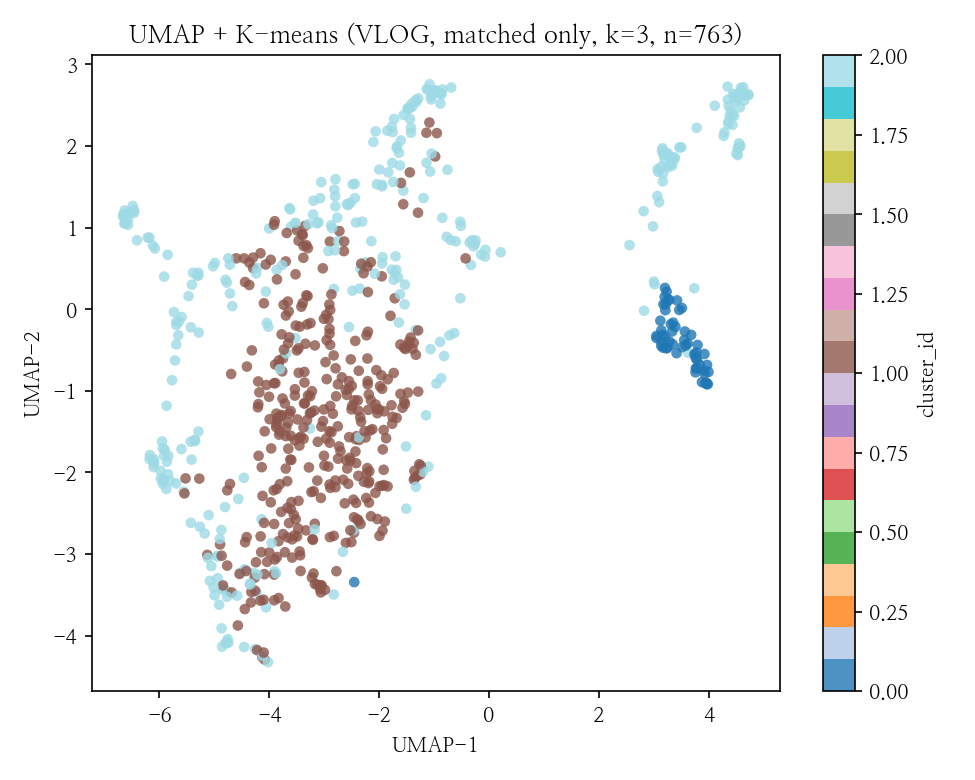

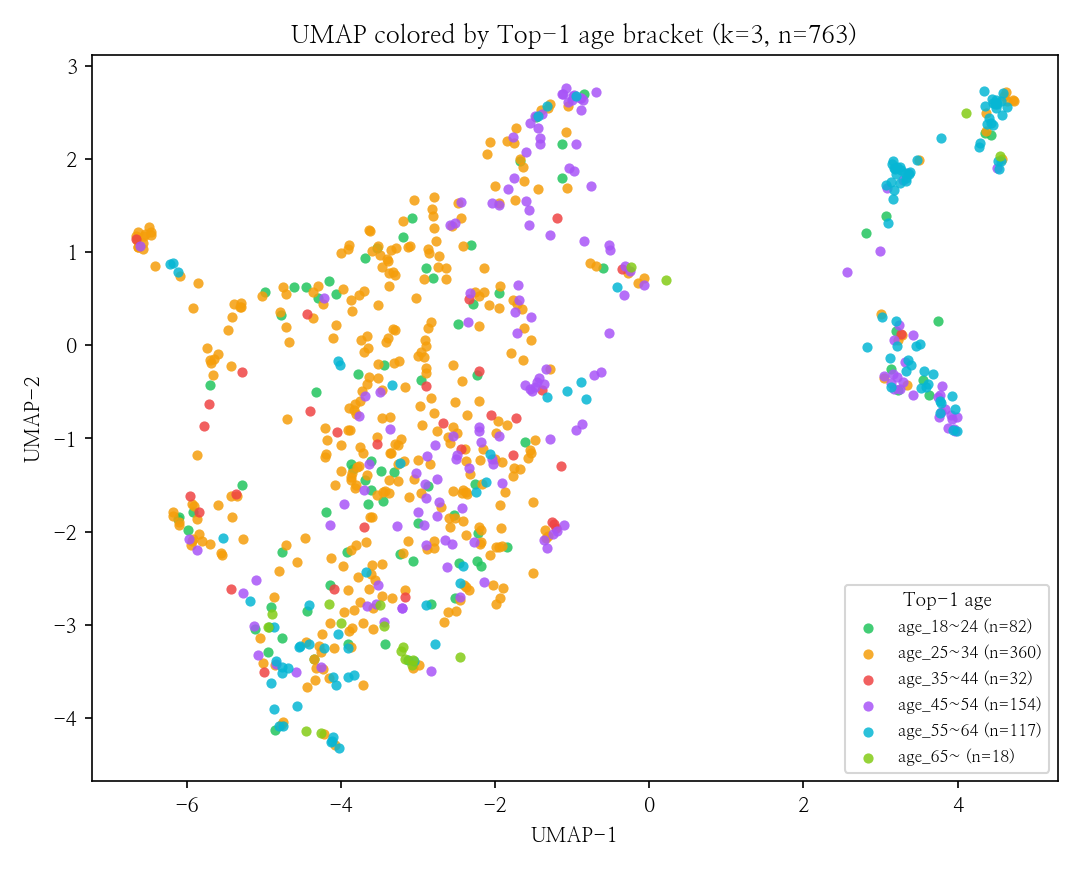

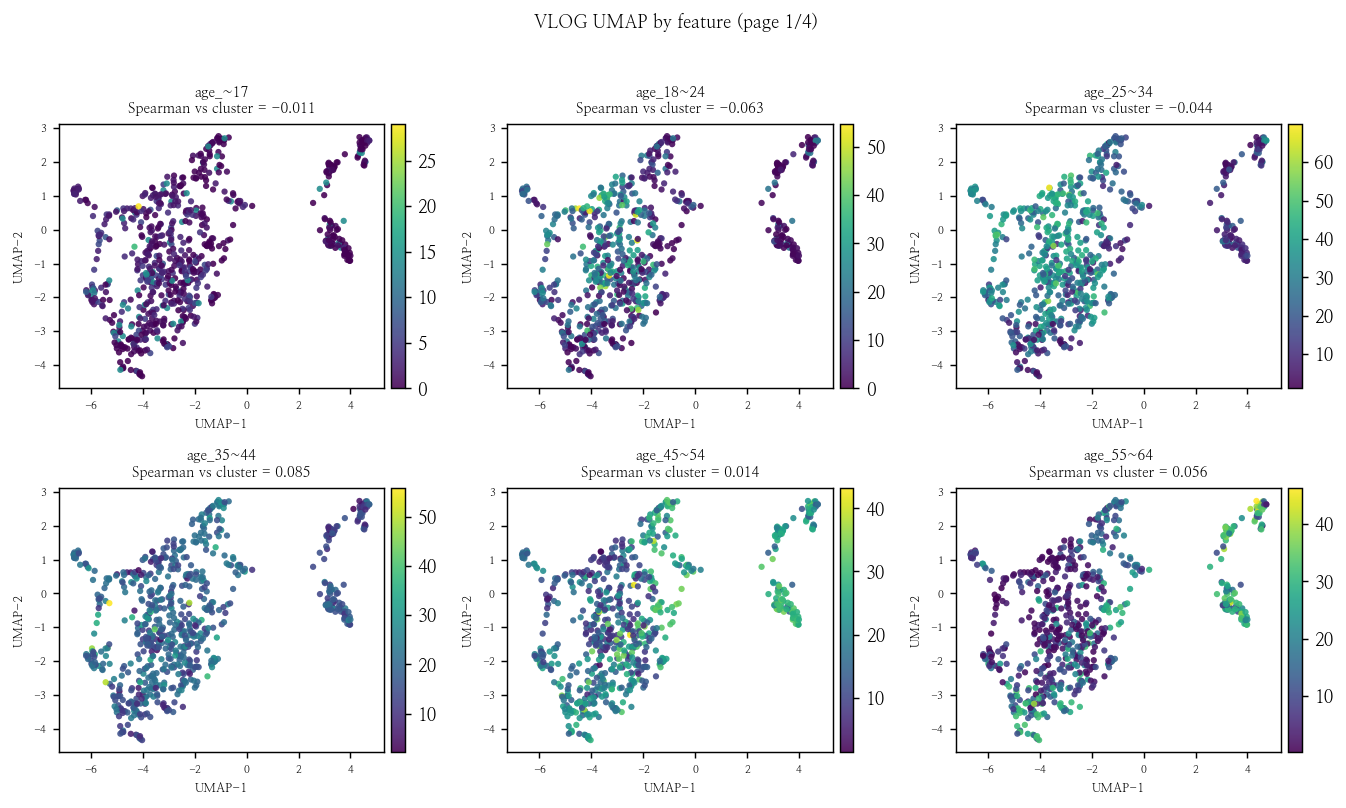

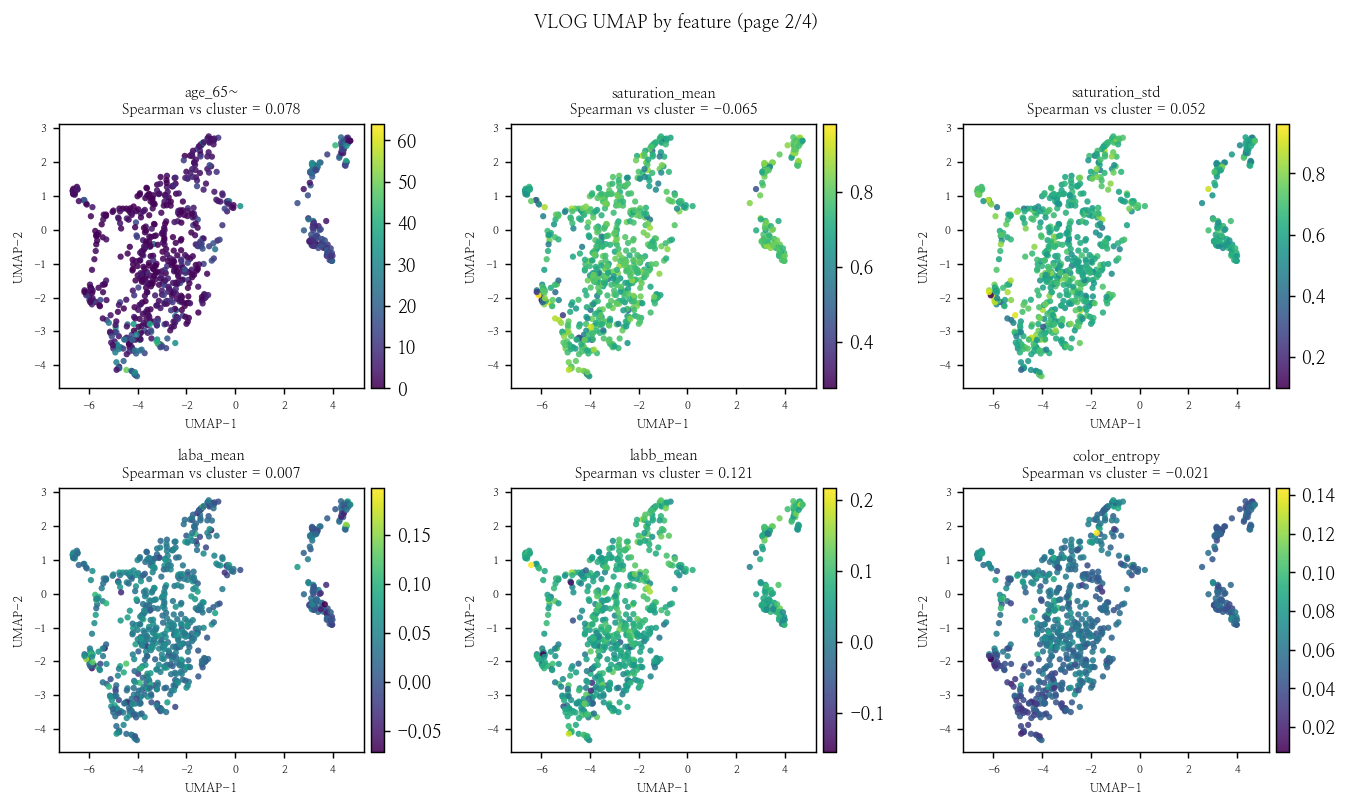

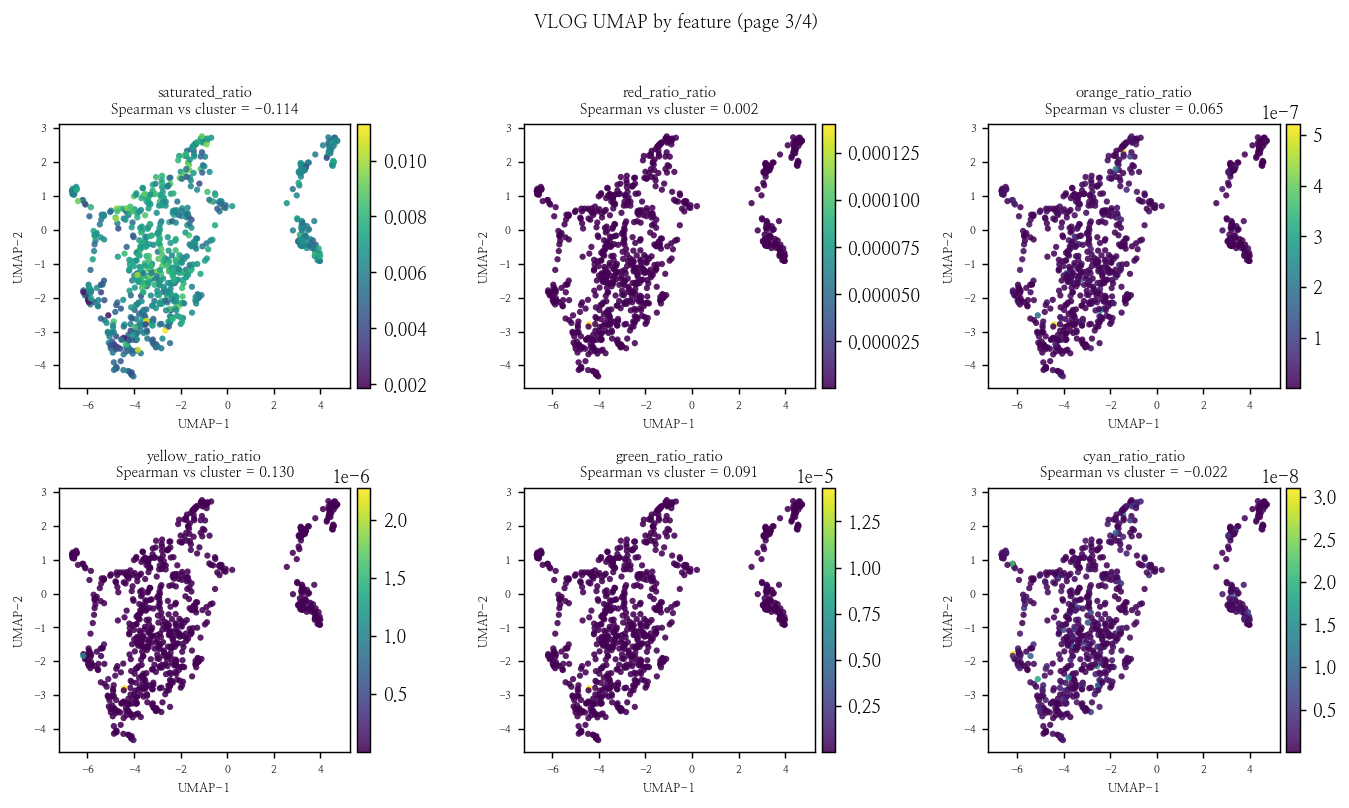

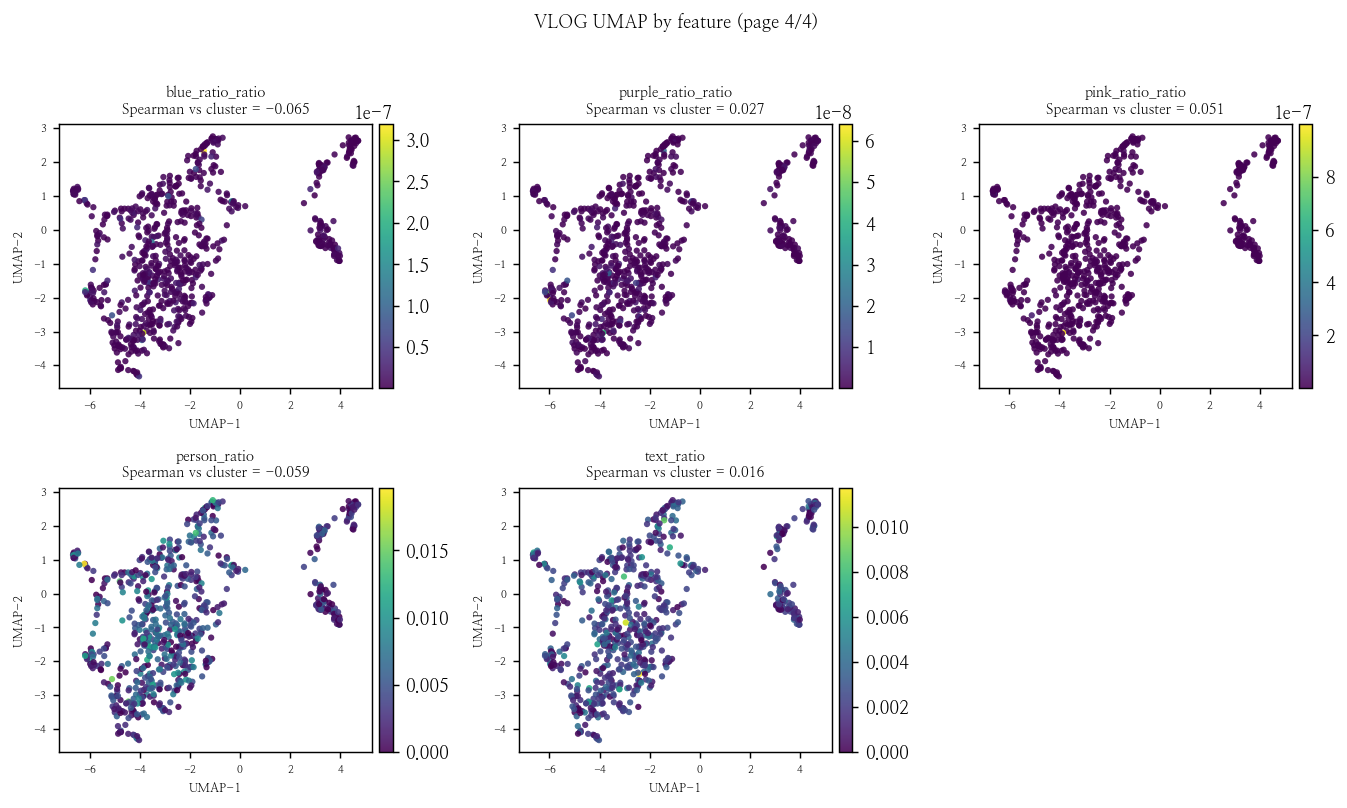

총 6장 표시


In [ ]:
from IPython.display import Image, display

# 노트북에서 보이는 크기(픽셀). 더 작게 보고 싶으면 700 등으로 낮추세요.
DISPLAY_UMAP_WIDTH_PX = 880
DISPLAY_KMEANS_WIDTH_PX = 640


def show_vlog_saved_umap_plots(
    grid_width: int = DISPLAY_UMAP_WIDTH_PX,
    kmeans_width: int = DISPLAY_KMEANS_WIDTH_PX,
) -> None:
    """저장된 PNG를 적당한 너비로 표시 (원격 Jupyter 렌더러 이슈 회피용)."""
    paths = []
    if VIZ_DIR.is_dir():
        paths.extend(sorted(VIZ_DIR.glob("umap_kmeans_k*.png")))
        paths.extend(sorted(VIZ_DIR.glob("umap_age_top1_argmax.png")))
        paths.extend(sorted(VIZ_DIR.glob("umap_feature_grid_*.png")))
    if not paths:
        print("표시할 PNG 없음. §7·§8·§8c 셀을 먼저 실행하세요.")
        return
    n = len(paths)
    for p in paths:
        w = kmeans_width if p.name.startswith("umap_kmeans") else grid_width
        display(Image(filename=str(p), width=w))
    print(f"총 {n}장 표시")


show_vlog_saved_umap_plots()


## 9. (선택) 클러스터 라벨 CSV 저장

In [ ]:
out_labels = ARTIFACTS_BASE / f"kmeans_labels_vlog_matched_k{best_k}.csv"
out_fields = ["channel_id", "channel_name", "cluster_id"]
name_col = "channel_name" if "channel_name" in merged.columns else "channel_name_meta"
with out_labels.open("w", encoding="utf-8-sig", newline="") as f:
    w = csv.DictWriter(f, fieldnames=out_fields)
    w.writeheader()
    for i, cid in enumerate(merged["channel_id"].values):
        w.writerow(
            {
                "channel_id": str(cid),
                "channel_name": str(merged[name_col].iloc[i]),
                "cluster_id": str(int(labels[i])),
            }
        )
print("저장:", out_labels)


저장: /home/urp_jwl2/urp_heeseok/[260302-260631] 26-1 URP/artifacts/VLOG/embeddings/dinov2-base/kmeans_labels_vlog_matched_k3.csv
